# SIR model: constrained optimization

Этот literate-скрипт решает задачу оптимизации: найти такие параметры,
которые минимизируют число умерших при ограничении на средний пик
заболеваемости `mean_peak <= 30%`.

In [1]:
using DrWatson
@quickactivate "lab_04_models"

ENV["GKSwstype"] = "100"

include(srcdir("sir_analysis.jl"))

scenario_comparison_plot (generic function with 1 method)

## Поиск допустимых решений

Используется многокритериальная оптимизация `BlackBoxOptim` (`:borg_moea`).
Оптимизируются параметры:
- `beta_und`;
- `detection_time`;
- `death_rate`.

In [2]:
peak_limit = 0.30
all_df, feasible_df, best = optimize_under_peak_constraint(; peak_limit)

first(feasible_df, min(10, nrow(feasible_df)))

Starting optimization with optimizer BlackBoxOptim.BorgMOEA{BlackBoxOptim.EpsBoxDominanceFitnessScheme{2, Float64, true, typeof(sum)}, BlackBoxOptim.ProblemEvaluator{Tuple{Float64, Float64}, BlackBoxOptim.IndexedTupleFitness{2, Float64}, BlackBoxOptim.EpsBoxArchive{2, Float64, BlackBoxOptim.EpsBoxDominanceFitnessScheme{2, Float64, true, typeof(sum)}}, BlackBoxOptim.FunctionBasedProblem{Main.var"##277".var"#28#29"{Int64, Int64, Dict{Symbol, Any}}, BlackBoxOptim.ParetoFitnessScheme{2, Float64, true, typeof(sum)}, BlackBoxOptim.ContinuousRectSearchSpace, Nothing}}, BlackBoxOptim.FitPopulation{BlackBoxOptim.IndexedTupleFitness{2, Float64}}, BlackBoxOptim.FixedGeneticOperatorsMixture, BlackBoxOptim.RandomBound{BlackBoxOptim.ContinuousRectSearchSpace}}
0.00 secs, 0 evals, 0 steps
pop.size=50 arch.size=0 n.restarts=0

Optimization stopped after 1 steps and 112.72 seconds
Termination reason: Max number of function evaluations (30) reached
Steps per second = 0.01
Function evals per second = 0.4

Row,beta_und,detection_time,death_rate,mean_peak,mean_deaths,feasible
,Float64,Int64,Float64,Float64,Float64,Bool
1,0.140852,4,0.0496646,0.001,0.0,true


## График допустимых решений

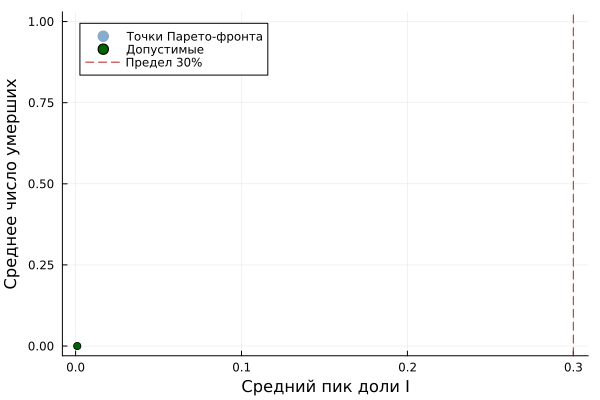

In [3]:
opt_plot = plot_constrained_optimization(all_df, feasible_df; peak_limit)
opt_plot

## Выводы

1. Алгоритм строит Pareto-фронт по двум критериям: средний пик и среднее число умерших.
2. Ограничение `mean_peak <= 30%` позволяет выбрать допустимые решения из фронта.
3. Лучшие решения смещаются к меньшей заразности, более раннему выявлению и меньшей смертности.